# Ejercicio Tema 1: Análisis exploratorio de datos y visualización con matplotlib/seaborn

### Juan Alcaraz, José Aguilar, Óscar Camacho, Adrián Carrasco, Javier Herrero, Clara Montalvá 

In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import mahalanobis
from matplotlib.colors import LinearSegmentedColormap

from itertools import combinations

import pandas as pd
import numpy as np

import seaborn as sns
from scipy.stats import mannwhitneyu

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.style.use("custom_style.mplstyle")

## 1. Preprocesado y estadística descriptiva

En primer lugar, importamos el dataset y lo preprocesamos.

In [2]:
# Dataset : Arritmias.csv

df_raw = pd.read_csv("data/Arritmias.csv")
cols = df_raw.columns[1:-4]

# Preproceso: 
#  a) cambiar separador decimal (, por .)
#  b) re-etiquetar AV como clase binaria (0/1)

# Cambio , por . en las series de excel formated_df: fdf
df = df_raw.copy()

for i in range(len(cols)):
      df[cols[i]] = df[cols[i]].str.replace(",", ".").astype(float)

cols = df.columns[1:-1]
X = df[cols].to_numpy()  # Marcadores de arritmia post-infarto
Y = df['AV'].to_numpy()  # AV: Arritmia Ventricular

print(df.head())

# Estudiar los 2 grupos de pacientes suministrados:  AV = 0 (no presenta arritmia) y AV = 1 (presenta arritmia)  
# Analizar y representar gráficamente la influencia de los marcadores suministrados en ambos grupos.
# Escribir un pequeño informe con el resumen de las gráficas generadas y las principales conclusiones extraídas (2-3 pp).

# Descripción de los marcadores utilizados :

# LV Mass(g)                : masa en gramos del ventrículo izquierdo.
# BZ+Core (g)               : masa en gramos de la zona infartada (core) + su borde (BZone)
# BZ (g, %)                 : masa en gramos de la zona de borde y su porcentaje
# Core (g, %)               : masa en gramos de la zona infartada y su porcentaje
# Channel_Mass (g)          : masa en gramos de los canales encontrados
# LVEF                      : fuerza de eyección del ventrículo
# Edad, Sexo
# AV                        : presenta arrimia (1), no presenta arritmia (0)


  PACIENTES  LV MASS (g)  BZ + CORE (g)  BZ + CORE (%)  BZ (g)  BZ (%)  \
0        P1        82.18           5.10           6.21    4.45    5.41   
1        P2       109.10          16.84          15.43   13.36   12.25   
2        P3       100.88           5.17           5.12    4.65    4.61   
3        P4        67.81           5.18           7.64    3.50    5.16   
4        P5       197.65          47.57          24.07   42.21   21.36   

   CORE (g)  CORE (%)  CHANNEL MASS (g)  LVEF  EDAD  SEXO  AV  
0      0.64      0.78              0.00    66    71     1   0  
1      3.48      3.19              8.05    36    53     1   1  
2      0.51      0.51              0.00    61    63     1   0  
3      2.48      3.66              2.37    63    74     2   0  
4      5.36      2.71             21.09    28    84     1   1  


Definimos los parámetros estilísticos que utilizaremos en todas las gráficas.

In [3]:

COLOR_AV0  = '#4C72B0'   # sin arritmia
COLOR_AV1  = '#DD8452'   # con arritmia
PALETTE    = {0: COLOR_AV0, 1: COLOR_AV1}
LABEL_AV0  = 'AV=0 (sin arritmia)'
LABEL_AV1  = 'AV=1 (con arritmia)'

sns.set_theme(style='whitegrid', font_scale=1.05)

A continuación, obtenemos estadísticas descriptivas por grupos.

In [4]:
marker_cols = df_raw.columns[1:-3]
df0 = df[df['AV'] == 0]
df1 = df[df['AV'] == 1]

stats_rows = []
for col in marker_cols:
    for av, grupo in [(0, df0), (1, df1)]:
        s = grupo[col]
        stats_rows.append({
            'Marcador': col, 'Grupo': f'AV={av}',
            'N': len(s), 'Media': round(s.mean(), 3),
            'Desv.Típica': round(s.std(), 3),
            'Mín': round(s.min(), 3), 'P25': round(s.quantile(.25), 3),
            'Mediana': round(s.median(), 3), 'P75': round(s.quantile(.75), 3),
            'Máx': round(s.max(), 3)
        })

desc_df = pd.DataFrame(stats_rows).set_index(['Marcador', 'Grupo'])
print('Estadística Descriptiva por Grupo')
display(desc_df)

Estadística Descriptiva por Grupo


N    Media  Desv.Típica    Mín      P25  Mediana  \
Marcador         Grupo                                                      
LV MASS (g)      AV=0   39  111.044       31.164  60.24   88.190  107.160   
                 AV=1   12  138.563       36.486  99.52  108.310  130.855   
BZ + CORE (g)    AV=0   39   18.344       19.017   0.34    6.260   11.690   
                 AV=1   12   34.699       28.190   4.77   17.335   24.700   
BZ + CORE (%)    AV=0   39   14.977       12.027   0.42    6.395   12.250   
                 AV=1   12   22.921       13.705   4.80   14.497   17.605   
BZ (g)           AV=0   39   13.439       12.666   0.27    4.585    8.100   
                 AV=1   12   24.172       17.572   3.45   13.660   16.525   
BZ (%)           AV=0   39   11.223        8.491   0.33    4.735    8.940   
                 AV=1   12   16.091        8.246   3.47   10.730   12.880   
CORE (g)         AV=0   39    5.001        7.209   0.07    1.025    3.430   
                 AV=1   12   10.528       11.573   1.15    3.142    5.460   
CORE (%)         AV=0   39    3.855        4.491   0.09    1.085    3.170   
                 AV=1   12    6.832        5.986   1.14    2.388    4.525   
CHANNEL MASS (g) AV=0   39    5.503        8.247   0.00    0.590    2.020   
                 AV=1   12    9.126        7.484   0.00    3.502    8.555   
LVEF             AV=0   39   52.000       11.943  30.00   42.500   55.000   
                 AV=1   12   41.167       10.803  28.00   34.250   37.500   

                            P75     Máx  
Marcador         Grupo                   
LV MASS (g)      AV=0   121.860  195.69  
                 AV=1   157.502  206.77  
BZ + CORE (g)    AV=0    22.450   88.61  
                 AV=1    48.600  106.50  
BZ + CORE (%)    AV=0    19.545   51.83  
                 AV=1    32.935   51.50  
BZ (g)           AV=0    18.350   53.20  
                 AV=1    34.705   65.73  
BZ (%)           AV=0    15.305   32.26  
                 AV=1    21.462   31.79  
CORE (g)         AV=0     4.775   35.41  
                 AV=1    13.295   40.76  
CORE (%)         AV=0     4.955   21.51  
                 AV=1    10.938   19.71  
CHANNEL MASS (g) AV=0     8.180   35.19  
                 AV=1    11.505   22.97  
LVEF             AV=0    62.500   72.00  
                 AV=1    49.000   59.00

Por último, realizamos un Test de Mann-Whitney U por marcador.

In [5]:

def significance_label(p):
    if p < 0.001: return '*'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

mw_results = []
pvalues = {}
for col in marker_cols:
    stat, p = mannwhitneyu(df0[col].dropna(), df1[col].dropna(),
                           alternative='two-sided')
    pvalues[col] = p
    mw_results.append({
        'Marcador': col, 'U-statistic': round(stat, 2),
        'p-value': round(p, 5), 'Significancia': significance_label(p)
    })

mw_df = pd.DataFrame(mw_results).sort_values('p-value').set_index('Marcador')
print('Test Mann-Whitney U - Diferencias entre AV=0 y AV=1')
display(mw_df)

sig_markers = [c for c in marker_cols if pvalues[c] < 0.05]
print(f'\nMarcadores significativos (p<0.05): {sig_markers}')

top5_markers = list(mw_df.head(5).index)

Test Mann-Whitney U - Diferencias entre AV=0 y AV=1


,U-statistic,p-value,Significancia
Marcador,,,
LVEF,356.0,0.00693,**
LV MASS (g),126.0,0.01698,*
BZ (g),132.0,0.02420,*
CORE (g),136.0,0.03037,*
BZ + CORE (g),136.0,0.03038,*
BZ + CORE (%),145.0,0.04939,*
CHANNEL MASS (g),146.5,0.05247,
BZ (%),152.0,0.07033,
CORE (%),155.5,0.08324,



Marcadores significativos (p<0.05): ['LV MASS (g)', 'BZ + CORE (g)', 'BZ + CORE (%)', 'BZ (g)', 'CORE (g)', 'LVEF']


## 2. Figura 1 – Distribuciones por marcador (Violin + Box + Strip)

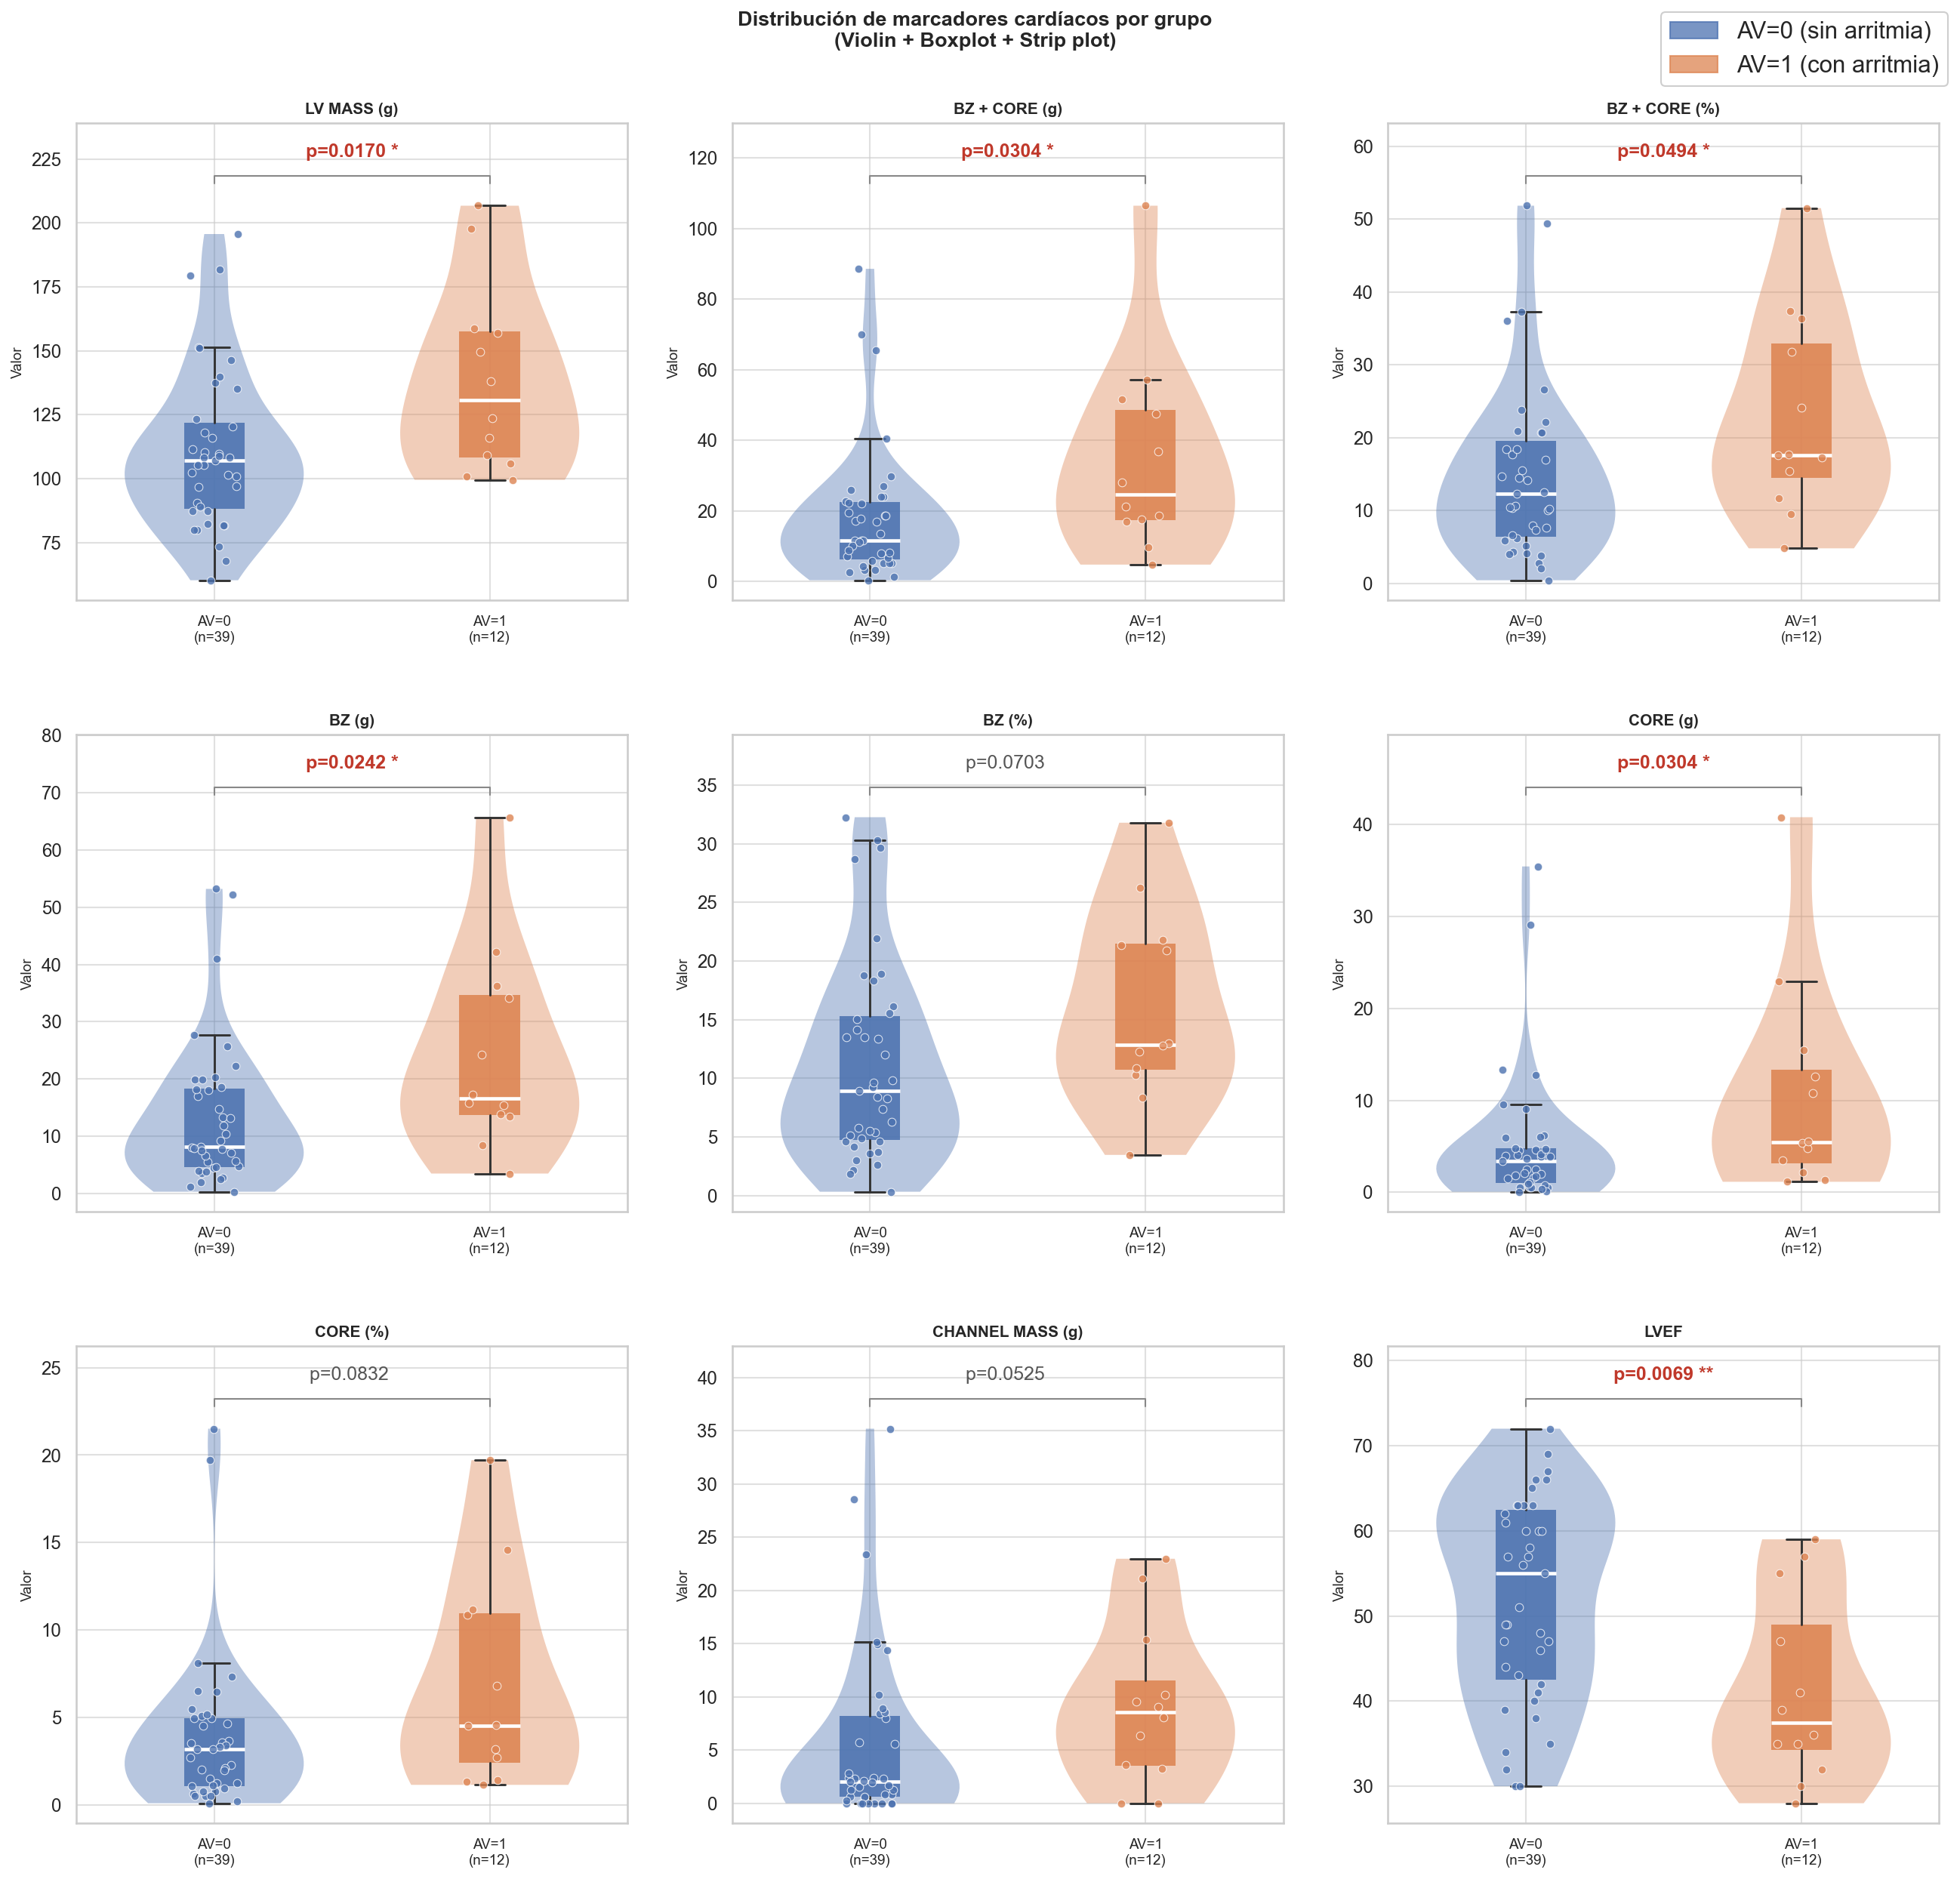

In [6]:


n_cols = 3
n_rows = int(np.ceil(len(marker_cols) / n_cols))
fig1, axes = plt.subplots(n_rows, n_cols, figsize=(5.8 * n_cols, 5.5 * n_rows))
axes = axes.flatten()


for idx, col in enumerate(marker_cols):
    ax = axes[idx]
    d0 = df0[col].dropna().values
    d1 = df1[col].dropna().values

    # Violin
    vp = ax.violinplot([d0, d1], positions=[0, 1], widths=0.65,
                       showmeans=False, showmedians=False, showextrema=False)
    for body, color in zip(vp['bodies'], [COLOR_AV0, COLOR_AV1]):
        body.set_facecolor(color); body.set_alpha(0.40); body.set_edgecolor('none')

    # Boxplot sin notches (evita artefactos con n=12)
    bp = ax.boxplot([d0, d1], positions=[0, 1], widths=0.22, notch=False,
                    patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.2),
                    whiskerprops=dict(linewidth=1.4, color='#333333'),
                    capprops=dict(linewidth=1.4, color='#333333'),
                    flierprops=dict(marker='', markersize=0),
                    boxprops=dict(linewidth=0))
    for patch, color in zip(bp['boxes'], [COLOR_AV0, COLOR_AV1]):
        patch.set_facecolor(color); patch.set_alpha(0.88)

    # Strip plot (jitter)
    for xpos, datos, color in [(0, d0, COLOR_AV0), (1, d1, COLOR_AV1)]:
        jitter = np.random.uniform(-0.09, 0.09, size=len(datos))
        ax.scatter(xpos + jitter, datos, color=color, alpha=0.80, s=26,
                   zorder=4, edgecolors='white', linewidths=0.5)

    # Título limpio
    ax.set_title(col, fontsize=10, fontweight='bold', pad=6)

    # Anotación p-value con línea de significancia entre grupos
    p = pvalues[col]
    sig = significance_label(p)
    color_sig = '#c0392b' if p < 0.05 else '#555555'
    y_max = max(d0.max(), d1.max())
    y_rng = y_max - min(d0.min(), d1.min())
    y_line = y_max + y_rng * 0.08
    y_text = y_line + y_rng * 0.04
    ax.plot([0, 0, 1, 1],
            [y_line - y_rng*0.02, y_line, y_line, y_line - y_rng*0.02],
            color='#888888', linewidth=1.0)
    ax.text(0.5, y_text, f'p={p:.4f} {sig}',
            ha='center', va='bottom', fontsize=12,
            color=color_sig, fontweight='bold' if p < 0.05 else 'normal')
    ax.set_ylim(top=y_text + y_rng * 0.10)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['AV=0\n(n=39)', 'AV=1\n(n=12)'], fontsize=9)
    ax.set_ylabel('Valor', fontsize=9)

for ax in axes[len(marker_cols):]:
    ax.set_visible(False)

patch0 = mpatches.Patch(color=COLOR_AV0, label=LABEL_AV0, alpha=0.75)
patch1 = mpatches.Patch(color=COLOR_AV1, label=LABEL_AV1, alpha=0.75)
fig1.legend(handles=[patch0, patch1], fontsize=15,
            framealpha=0.95)
fig1.suptitle('Distribución de marcadores cardíacos por grupo\n(Violin + Boxplot + Strip plot)',
              fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout(h_pad=3.5, w_pad=2.0)
plt.show()

*Marcadores significativos (p < 0,05):*

Los 6 marcadores significativos comparten un patrón visual común: los violines de ambos grupos están *desplazados verticalmente* con escaso solapamiento entre sus cuerpos principales, y los boxplots tienen medianas claramente separadas. El caso más extremo es *LVEF* (p = 0,0069, \\), donde los dos violines prácticamente no se tocan: AV=0 concentra su masa en 50–65% y AV=1 en 30–50%. En el extremo opuesto, *BZ + CORE (%)* (p = 0,0494, \*) está justo en el límite porque, aunque la tendencia existe, los violines comparten una zona de solapamiento amplia en torno al 10–25%, lo que reduce la confianza del test.

*Marcadores no significativos (p ≥ 0,05):*

Los 3 marcadores no significativos tienen en común que sus violines *se solapan extensamente* y los puntos del strip de AV=0 alcanzan los mismos valores máximos que AV=1. En *BZ (%)* y *CORE (%)* la causa es la alta dispersión interna de AV=0, cuyos violines tienen colas superiores largas que invaden el rango de AV=1. En *CHANNEL MASS (g)* (p = 0,0525, ns) hay un caso especialmente ilustrativo: existe un único outlier en AV=0 visible en el strip plot en torno a 35 g que estira el violin hacia arriba artificialmente, inflando la varianza del grupo y elevando el p-value por encima del umbral. Sin ese punto atípico, este marcador probablemente resultaría significativo.

*Patrón general:*

Los marcadores en *gramos absolutos* son sistemáticamente más significativos que los *porcentuales*. Esto indica que lo clínicamente relevante es la cantidad absoluta de tejido dañado: un paciente con un ventrículo grande puede tener un porcentaje de infarto moderado pero una masa necrótica en gramos suficientemente elevada como para generar el sustrato arrítmico.

## 3. Figura 2 – Heatmap de correlaciones por grupo

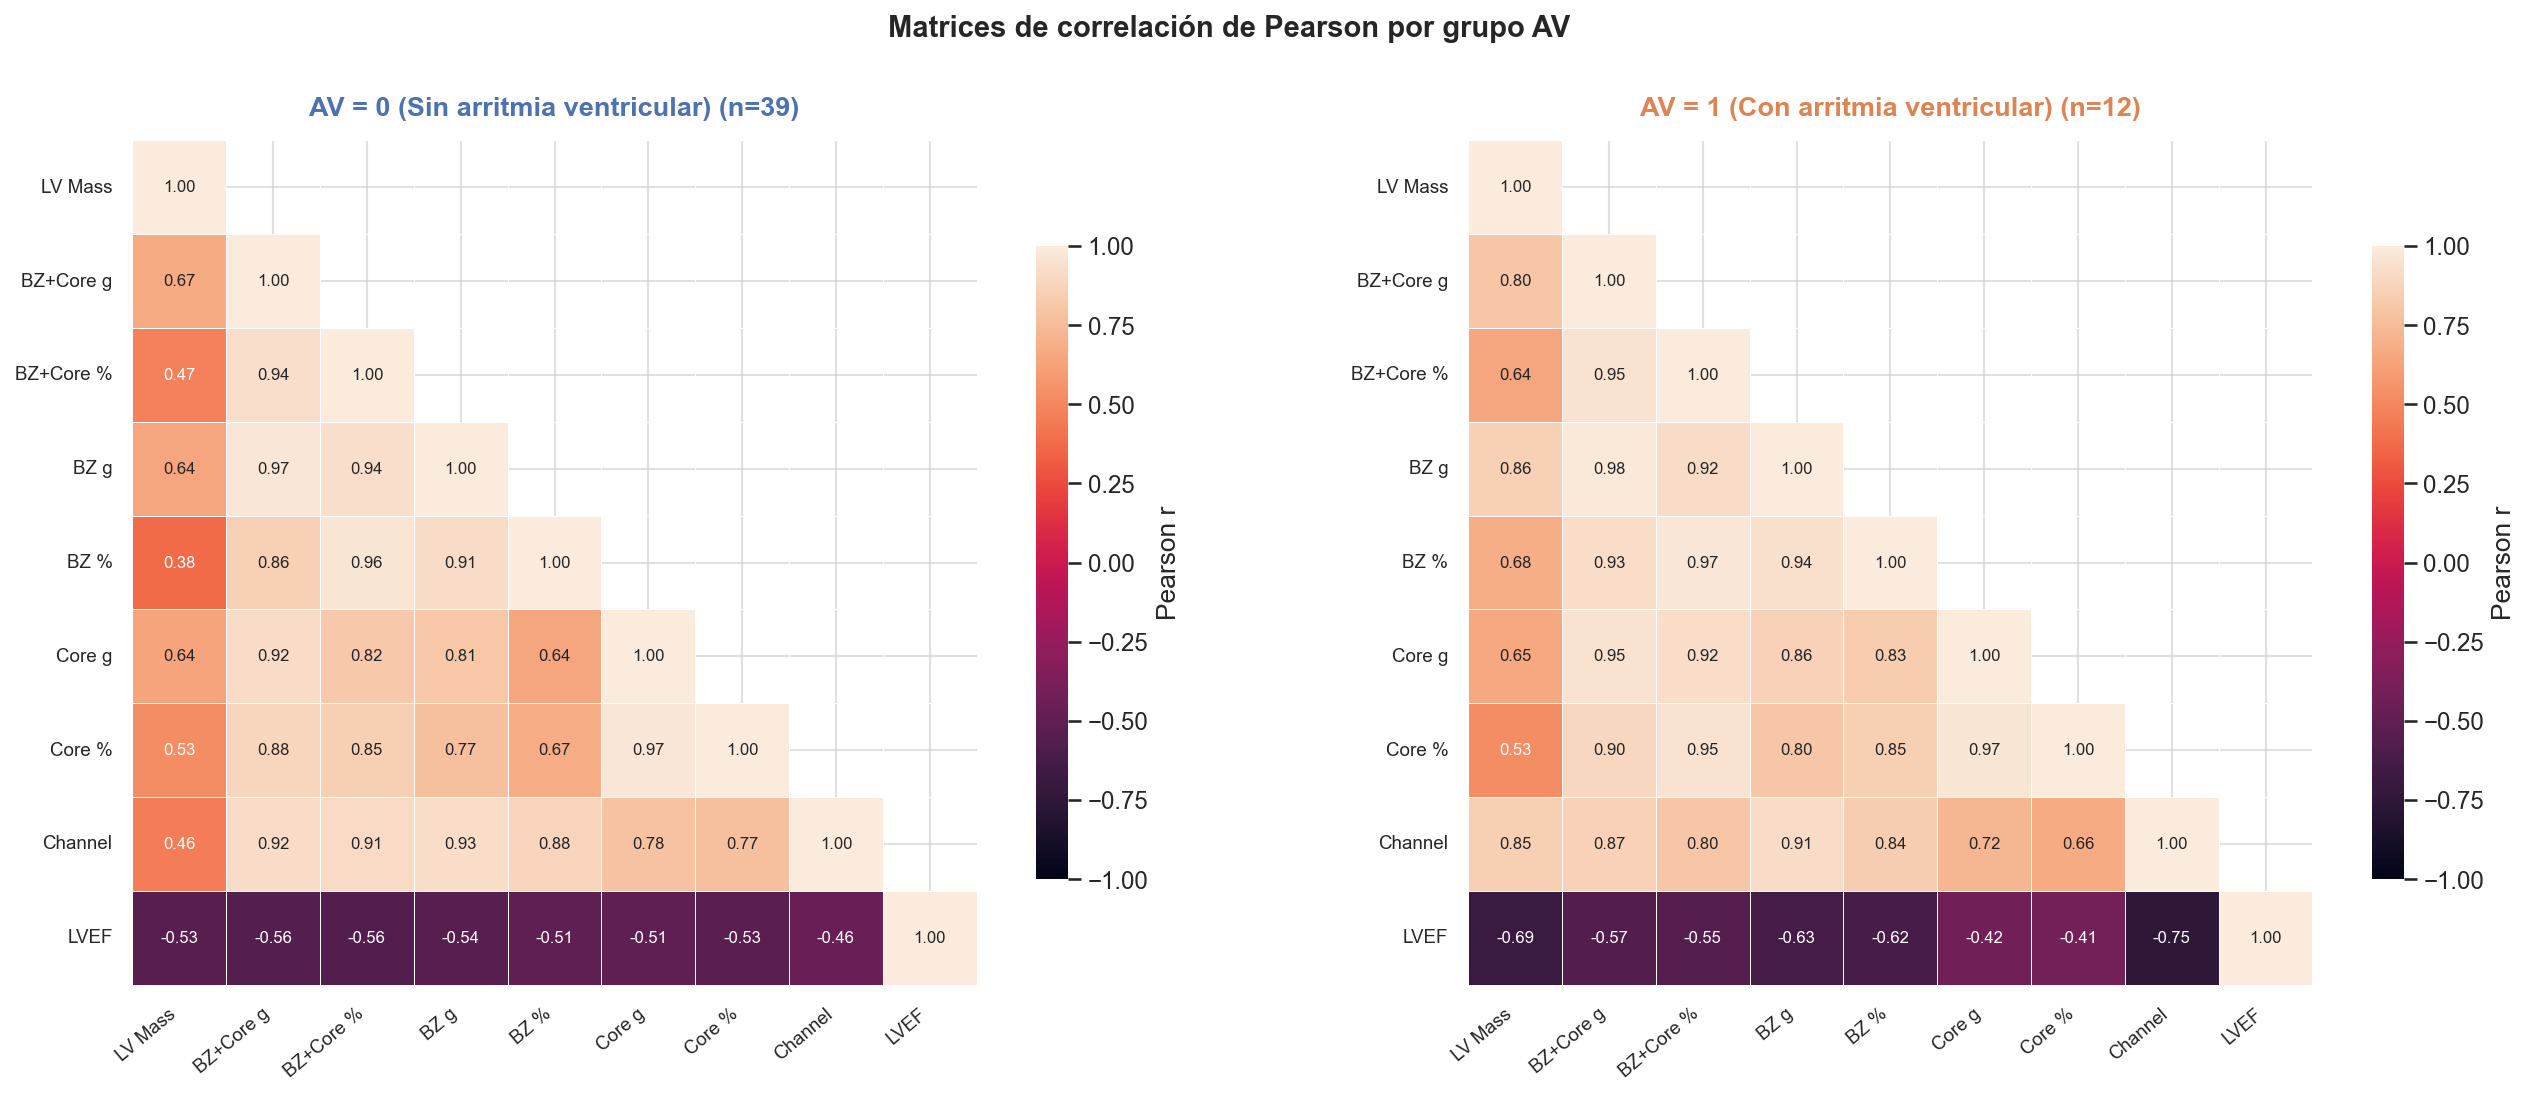

Top-5 pares con mayor diferencia de correlación entre grupos


,Var A,Var B,|Δr|
0,Channel,LV Mass,0.389618
1,BZ %,LV Mass,0.302150
2,LVEF,Channel,0.294585
3,BZ g,LV Mass,0.213743
4,Core g,BZ %,0.189274


In [7]:
# Objetivo: detectar si las relaciones lineales entre marcadores morfológicos
# cambian estructuralmente en presencia de arritmia ventricular.


# Etiquetas cortas para los ejes (mejor legibilidad)
short_labels = {
    'LV MASS (g)'     : 'LV Mass',
    'BZ + CORE (g)'   : 'BZ+Core g',
    'BZ + CORE (%)'   : 'BZ+Core %',
    'BZ (g)'          : 'BZ g',
    'BZ (%)'          : 'BZ %',
    'CORE (g)'        : 'Core g',
    'CORE (%)'        : 'Core %',
    'CHANNEL MASS (g)': 'Channel',
    'LVEF'            : 'LVEF'
}

def plot_corr_heatmap(ax, data, title, color_title):
    # Renombrar columnas a etiquetas cortas
    subset = data[marker_cols].rename(columns=short_labels)
    corr   = subset.corr(method='pearson')

    # Máscara: True en triángulo superior (sin la diagonal)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    sns.heatmap(
        corr,
        ax=ax,
        mask=mask,
        vmin=-1, vmax=1, # centrado en 0
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
        linewidths=0.4,
        linecolor='white',
        square=True,
        cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}
    )

    # Rotación de etiquetas
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  ha='right', fontsize=9)

    # Título con color del grupo
    ax.set_title(title, fontsize=13, fontweight='bold', color=color_title, pad=12)
    return corr


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matrices de correlación de Pearson por grupo AV',
             fontsize=14, fontweight='bold', y=1.02)

corr0 = plot_corr_heatmap(axes[0], df0,
                          title=f'AV = 0 (Sin arritmia ventricular) (n={len(df0)})',
                          color_title=COLOR_AV0)

corr1 = plot_corr_heatmap(axes[1], df1,
                          title=f'AV = 1 (Con arritmia ventricular) (n={len(df1)})',
                          color_title=COLOR_AV1)

plt.tight_layout()
plt.show()

# ── Tabla de diferencias de correlación (|r_AV1 - r_AV0|) ────────────────────
diff_corr = (corr1 - corr0).abs()
# Solo triángulo inferior
mask_lower = np.triu(np.ones_like(diff_corr, dtype=bool), k=0)
diff_corr_masked = diff_corr.where(~mask_lower)
top_diffs = (
    diff_corr_masked.stack()
    .reset_index()
    .rename(columns={'level_0': 'Var A', 'level_1': 'Var B', 0: '|Δr|'})
    .sort_values('|Δr|', ascending=False)
    .head(5)
    .reset_index(drop=True)
)
print('Top-5 pares con mayor diferencia de correlación entre grupos')
display(top_diffs)

En los dos grupos se observa una correlación positiva muy alta entre `BZ+Core (g)`, `BZ (g)` y `Core (g)`. Esto es esperable ya que todas son subregiones en gramos de la misma estructura anatómica.

Para AV = 1 tenemos que la correlación de Channel Mass con los marcadores de zona infartada (`Core`, `BZ`) tiende a ser más elevada que en AV=0.
`LVEF` muestra correlaciones negativas más marcadas con las variables de masa infartada en AV=1.

En AV = 0 las correlaciones entre variables en porcentaje (`BZ %`, `Core %`, `BZ+Core %`) y las variables en gramos son más consistentes, lo que indica que la distribución relativa de las zonas infartadas es más homogénea en pacientes sin arritmia.

Los heatmaps revelan que la estructura de correlación no es idéntica entre grupos, lo que apoya la hipótesis de que la presencia de arritmia ventricular va acompañada de un cambio en las características del miocardio, y no solo de un incremento cuantitativo de los marcadores. Esto justifica el uso de modelos multivariantes en lugar de análisis marcador a marcador para la predicción de AV.

## 4. Figura 3 – Pairplot de marcadores más discriminantes

Top 5 marcadores más discriminantes (menor p-value):
  LVEF                            p = 0.00693
  LV MASS (g)                     p = 0.01698
  BZ (g)                          p = 0.02420
  CORE (g)                        p = 0.03037
  BZ + CORE (g)                   p = 0.03038


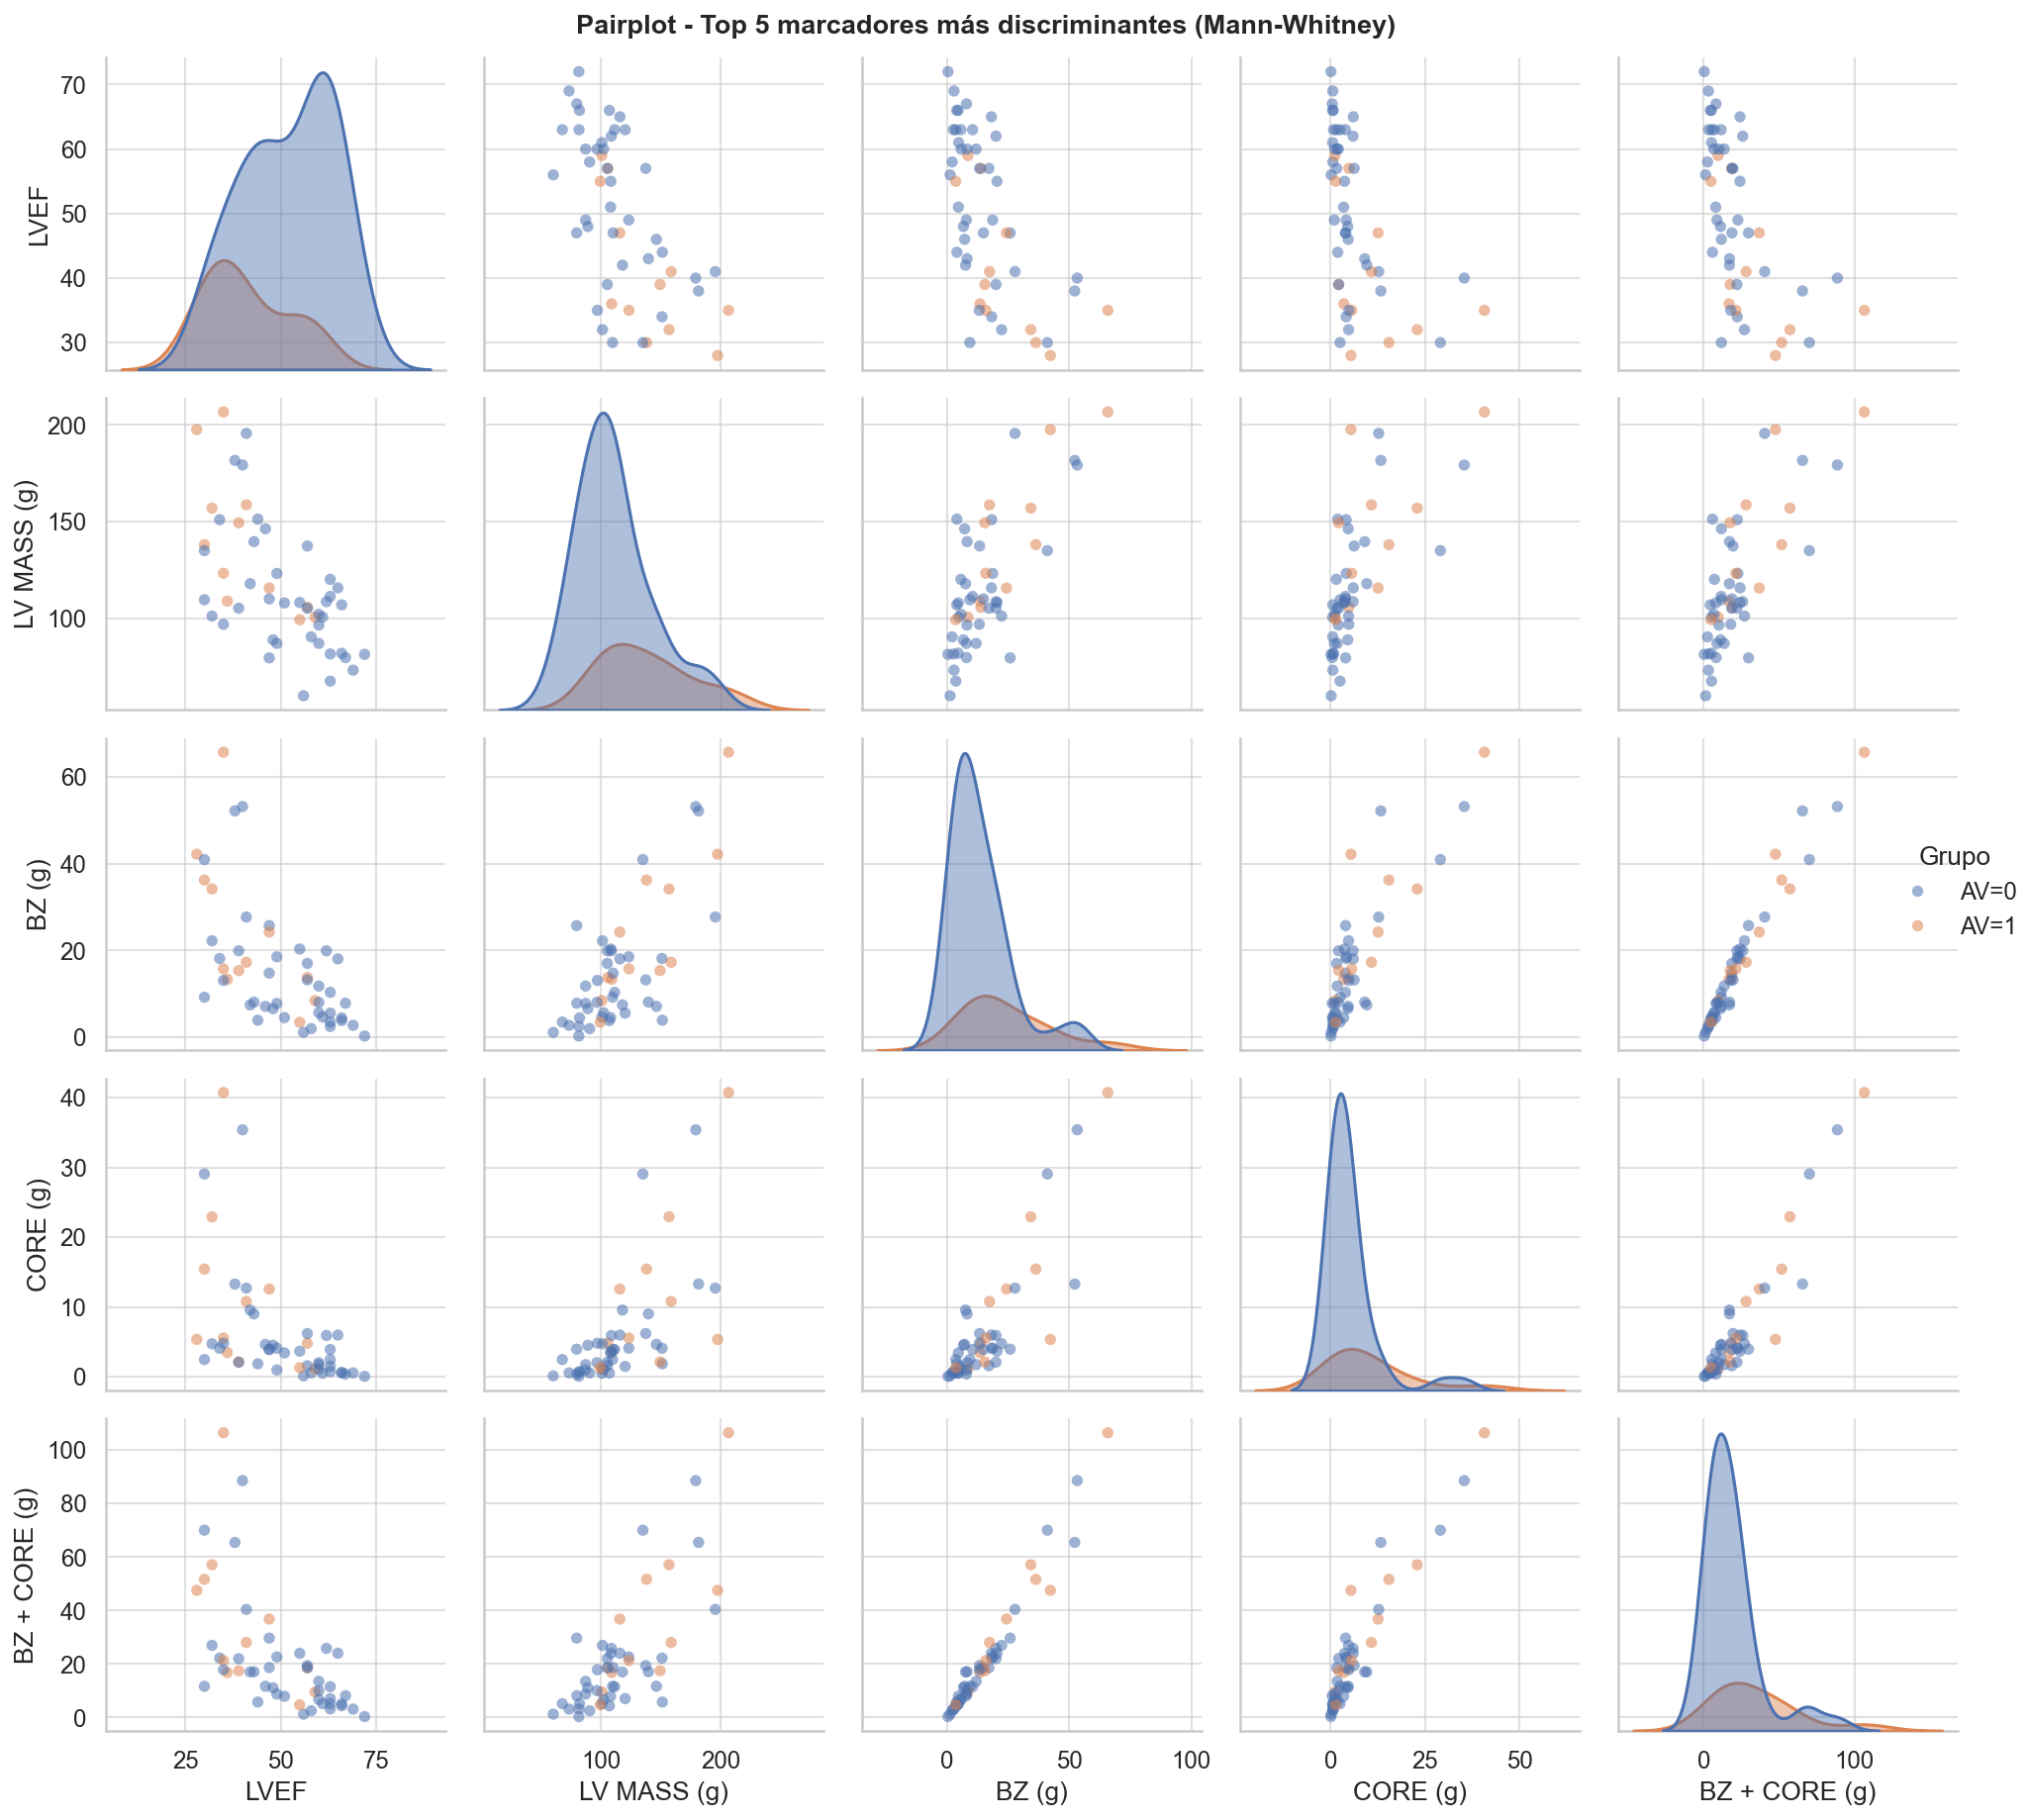

In [8]:
pvalues = {}

for col in marker_cols:
    _, p = mannwhitneyu(df0[col], df1[col],
                        alternative="two-sided", nan_policy="omit")
    pvalues[col] = p

top5 = sorted(pvalues, key=pvalues.get)[:5]
print("Top 5 marcadores más discriminantes (menor p-value):")
for col in top5:
    print(f"  {col:30s}  p = {pvalues[col]:.5f}")


df_plot = df[top5 + ["AV"]].copy()
df_plot["AV"] = df_plot["AV"].map({0: "AV=0", 1: "AV=1"})

palette_str = {"AV=0": PALETTE[0], "AV=1": PALETTE[1]}

g = sns.pairplot(
    df_plot,
    hue="AV",
    palette=palette_str,
    diag_kind="kde",          # KDE en la diagonal
    plot_kws={"alpha": 0.55, "s": 30, "edgecolors": "none"},
    diag_kws={"fill": True, "alpha": 0.45, "linewidth": 1.5},
    corner=False,
)

# Título global
g.figure.suptitle("Pairplot - Top 5 marcadores más discriminantes (Mann-Whitney)")

# Ajustar leyenda
g.legend.set_title("Grupo")
g._legend.set_bbox_to_anchor((1.02, 0.5))

# Rotar etiquetas del eje x para legibilidad
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel())
        ax.set_ylabel(ax.get_ylabel())

plt.tight_layout()
plt.show()

La gráfica muestra el pairplot de los 5 marcadores más discriminantes entre grupos. En la diagonal se observa que LVEF es el único marcador con distribuciones claramente separadas AV=0 (azul) concentrado en valores altos y AV=1 (naranja) en valores bajos, consistente con su p-value más bajo (p = 0.007). Los marcadores de zona infartada (BZ, Core, BZ+Core) muestran distribuciones muy asimétricas y solapadas, con AV=1 desplazado hacia valores más altos pero con escasa separación visual.
En los scatter off-diagonal, el par LVEF es el que muestra mayor separación entre nubes.

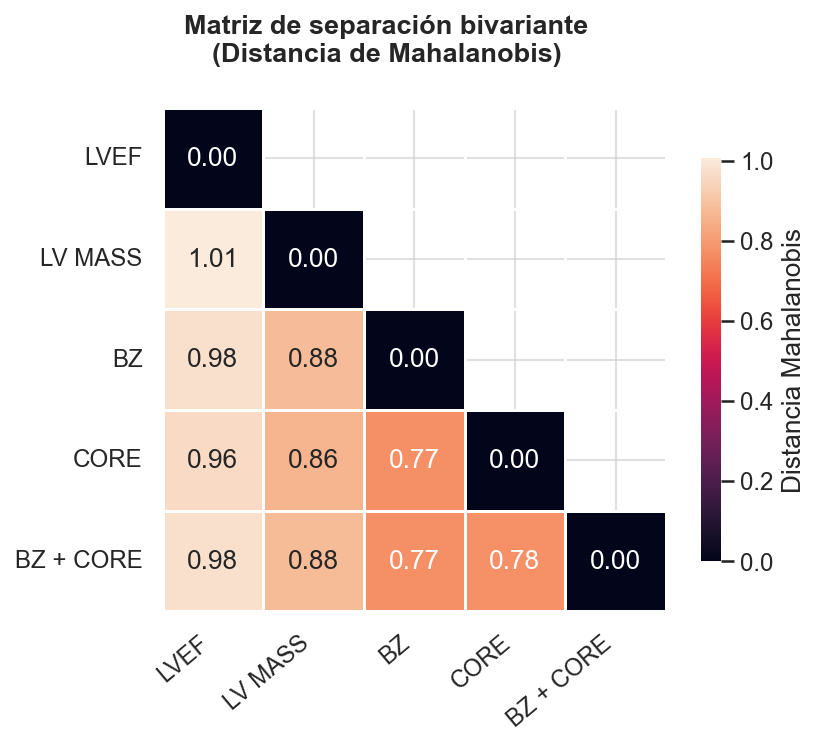

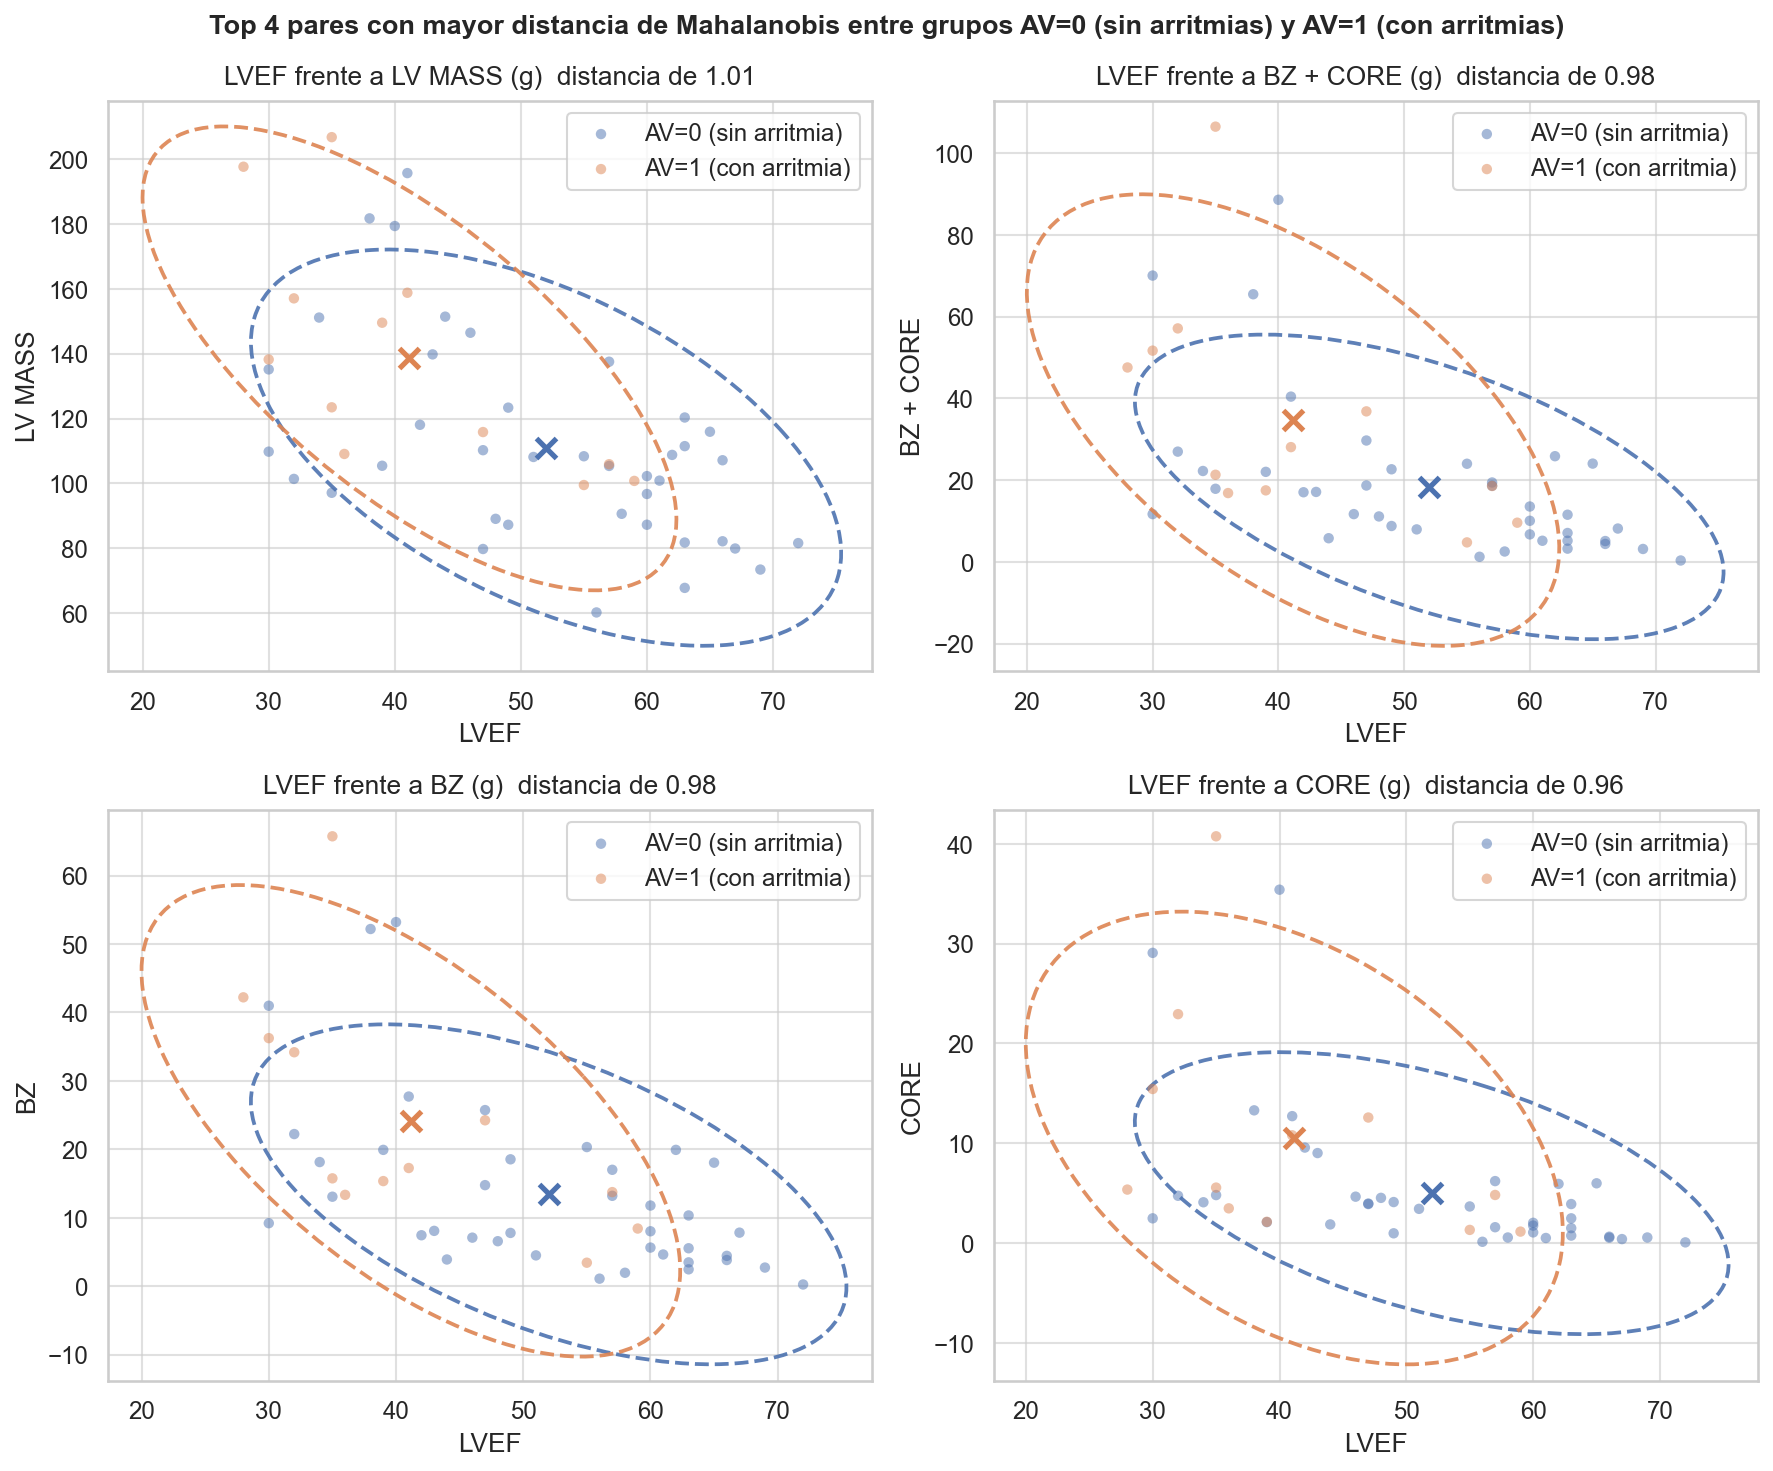

In [9]:
feature_cols = marker_cols.tolist()

pvalues = {}
for col in feature_cols:
    _, p = mannwhitneyu(df0[col], df1[col],
                        alternative="two-sided", nan_policy="omit")
    pvalues[col] = p

top5 = sorted(pvalues, key=pvalues.get)[:5]

def mahal_pair(col_a, col_b):
    X0 = df0[[col_a, col_b]].dropna().values
    X1 = df1[[col_a, col_b]].dropna().values
    mu0, mu1 = X0.mean(axis=0), X1.mean(axis=0)
    n0, n1   = len(X0), len(X1)
    cov_pooled = ((n0-1)*np.cov(X0, rowvar=False) +
                  (n1-1)*np.cov(X1, rowvar=False)) / (n0+n1-2)
    try:
        return mahalanobis(mu0, mu1, np.linalg.inv(cov_pooled))
    except np.linalg.LinAlgError:
        return np.nan

pairs        = list(combinations(top5, 2))
pair_scores  = {(a, b): mahal_pair(a, b) for a, b in pairs}
sorted_pairs = sorted(pair_scores.items(), key=lambda x: -x[1])
top4_pairs   = sorted_pairs[:4]

n     = len(top5)
short = [c.split("(")[0].strip() for c in top5]
D     = np.zeros((n, n))
for (a, b), d in pair_scores.items():
    i, j = top5.index(a), top5.index(b)
    D[i, j] = d
    D[j, i] = d


fig_a, ax_heat = plt.subplots(figsize=(6, 5), facecolor="white")
fig_a.suptitle("Matriz de separación bivariante\n(Distancia de Mahalanobis)")

mask_upper = np.triu(np.ones((n, n), dtype=bool), k=1)

sns.heatmap(
    D,
    mask=mask_upper,
    ax=ax_heat,
    annot=True,
    fmt=".2f",
    vmin=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Distancia Mahalanobis"},
    xticklabels=short,
    yticklabels=short,
)
ax_heat.set_xticklabels(ax_heat.get_xticklabels(), rotation=40, ha="right")
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


fig_b, axes = plt.subplots(2, 2, figsize=(12, 10), facecolor="white")
fig_b.suptitle("Top 4 pares con mayor distancia de Mahalanobis entre grupos AV=0 (sin arritmias) y AV=1 (con arritmias)")

for idx, ((col_a, col_b), d) in enumerate(top4_pairs):
    ax = axes[idx // 2][idx % 2]


    for grp, color, label in [(0, COLOR_AV0, LABEL_AV0), (1, COLOR_AV1, LABEL_AV1)]:
        sub  = df[df["AV"] == grp]
        vals = sub[[col_a, col_b]].dropna().values
        ax.scatter(vals[:, 0], vals[:, 1],
                   c=color, alpha=0.50, s=25, edgecolors="none", label=label)

        mu      = vals.mean(axis=0)
        cov     = np.cov(vals, rowvar=False)
        eigvals, eigvecs = np.linalg.eigh(cov)
        order   = eigvals.argsort()[::-1]
        eigvals, eigvecs = eigvals[order], eigvecs[:, order]
        angle   = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
        ell = Ellipse(xy=mu,
                      width=2*1.96*np.sqrt(eigvals[0]),
                      height=2*1.96*np.sqrt(eigvals[1]),
                      angle=angle,
                      edgecolor=color, facecolor="none",
                      lw=1.8, linestyle="--", alpha=0.9)
        ax.add_patch(ell)
        ax.plot(mu[0], mu[1], marker="x", ms=10, mew=2.5, color=color, zorder=5)
        
    short_a = col_a.split("(")[0].strip()
    short_b = col_b.split("(")[0].strip()
    ax.set_xlabel(short_a)
    ax.set_ylabel(short_b)
    ax.set_title(f"{col_a} frente a {col_b}  distancia de {d:.2f}")
    ax.legend()
plt.tight_layout()
plt.show()

En los 4 pares analizados, LVEF es consistentemente el marcador más discriminante del eje X: los pacientes con arritmia (AV=1, naranja) presentan valores de LVEF más bajos, mientras que los sin arritmia (AV=0, azul) se agrupan en valores más altos. Esto indica que una menor fuerza de eyección ventricular se asocia claramente con la presencia de arritmia.

En el eje Y, todos los marcadores de zona infartada (LV Mass, BZ+Core, BZ y Core) muestran el patrón opuesto: los centroides de AV=1 están siempre por encima de los de AV=0, confirmando que mayor masa infartada se asocia a arritmia. El par con mayor separación es LVEF frente a LV Mass (d = 1.01), el único que supera la distancia de Mahalanobis de 1.

## 5. Figura 4 – Variables demográficas (Edad y Sexo) vs AV

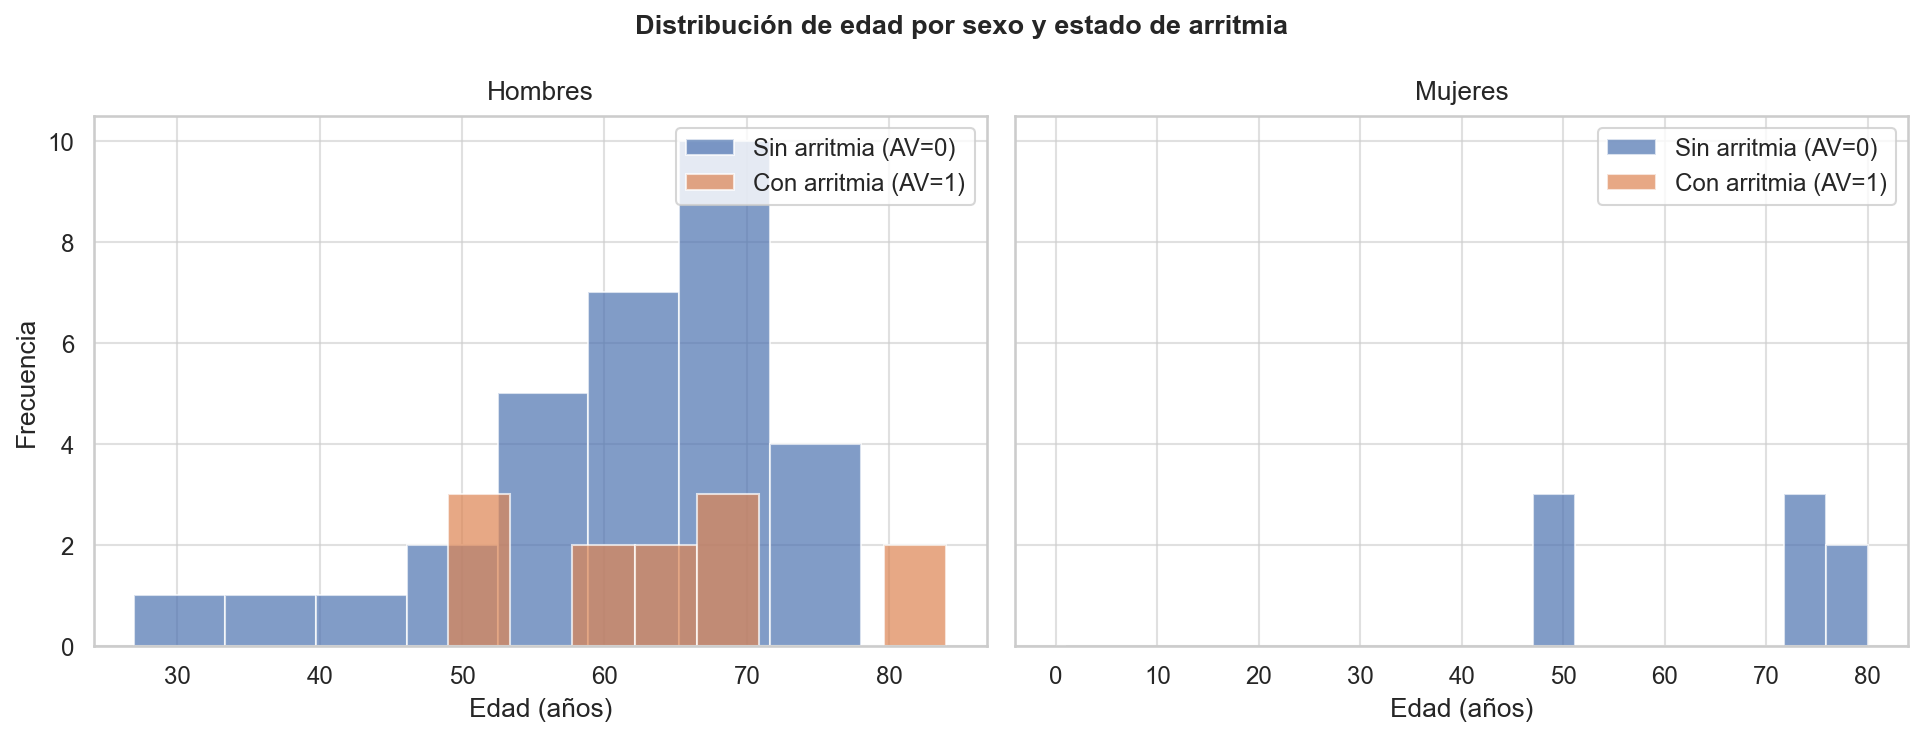

In [16]:

# Extraer datos
hombres_Aritmia = df[(df["SEXO"] == 1) & (df["AV"] == 1)]["EDAD"]
hombres_NoAritmia = df[(df["SEXO"] == 1) & (df["AV"] == 0)]["EDAD"]
mujeres_Aritmia = df[(df["SEXO"] == 2) & (df["AV"] == 1)]["EDAD"]
mujeres_NoAritmia = df[(df["SEXO"] == 2) & (df["AV"] == 0)]["EDAD"]
 
# Crear figura con 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('Distribución de edad por sexo y estado de arritmia')
 
n_bins = 8
 
ax1 = axes[0]
ax1.hist(hombres_NoAritmia, bins=n_bins, alpha=0.7, label='Sin arritmia (AV=0)', 
         color=COLOR_AV0, edgecolor='white')
ax1.hist(hombres_Aritmia, bins=n_bins, alpha=0.7, label='Con arritmia (AV=1)', 
         color=COLOR_AV1, edgecolor='white')
ax1.set_xlabel('Edad (años)')
ax1.set_ylabel('Frecuencia')
ax1.set_title(f'Hombres')
ax1.legend(loc='upper right')
ax1.set_axisbelow(True)
 
ax2 = axes[1]
ax2.hist(mujeres_NoAritmia, bins=n_bins, alpha=0.7, label='Sin arritmia (AV=0)', 
         color=COLOR_AV0, edgecolor='white')
ax2.hist(mujeres_Aritmia, bins=n_bins, alpha=0.7, label='Con arritmia (AV=1)', 
         color=COLOR_AV1, edgecolor='white')
ax2.set_xlabel('Edad (años)')
ax2.set_title(f'Mujeres')
ax2.legend(loc='upper right')
ax2.set_axisbelow(True)
 
plt.tight_layout()
plt.show()

Hombres: Presenta una distribución bimodal clara con concentración en 60-70 años. Los casos de arritmia (naranja) aparecen exclusivamente a partir de los 50 años, solapándose parcialmente con el grupo sin arritmia pero con tendencia a edades más avanzadas. La edad no es un predictor independiente, pero actúa como umbral de riesgo.

Mujeres: Muestra altamente desbalanceada que impide extraer conclusiones razonables. Los pocos casos disponibles (máximo 3 por grupo) se distribuyen dispersos, lo que invalida cualquier análisis por sexo.

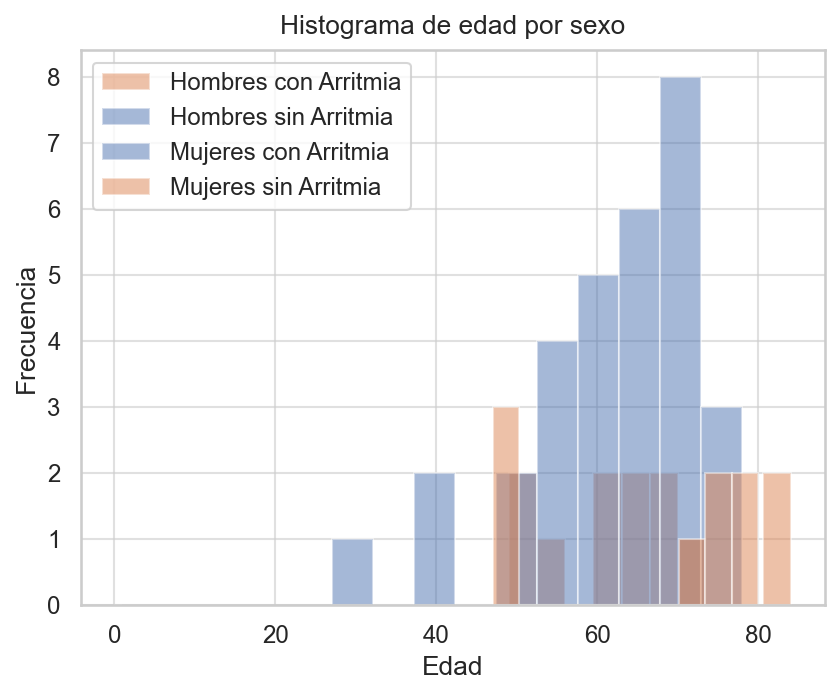

In [ ]:

pd.crosstab(df["SEXO"], df["AV"])

hombres_Aritmia = df[(df["SEXO"] == 1) & (df["AV"] == 1)]["EDAD"]
hombres_NoAritmia = df[(df["SEXO"] == 1) & (df["AV"] == 0)]["EDAD"]
mujeres_Aritmia = df[(df["SEXO"] == 2) & (df["AV"] == 1)]["EDAD"]
mujeres_NoAritmia = df[(df["SEXO"] == 2) & (df["AV"] == 0)]["EDAD"]

n = 10
plt.hist(hombres_Aritmia, bins=n, alpha=0.5, label="Hombres con Arritmia", color = COLOR_AV1)
plt.hist(hombres_NoAritmia, bins=n, alpha=0.5, label="Hombres sin Arritmia", color = COLOR_AV0)
plt.hist(mujeres_Aritmia, bins=n, alpha=0.5, label="Mujeres con Arritmia")
plt.hist(mujeres_NoAritmia, bins=n, alpha=0.5, label="Mujeres sin Arritmia")

plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Histograma de edad por sexo")
plt.legend()
plt.show()

Primero hablaremos sobre la variable de sexo, y es que hay un gran desbalance entre las dos clases, solo hay $8$ instancias de mujeres frente a las más de $40$ de los hombres, además de que son realmente muy pocos los datos de mujeres de los que se disponen, por tanto, no podemos considerarlo una variable significativa, una buena opción sería restringuirnos a inversigar el caso de los hombres, y eliminar la variable de sexo que primeramente no aporta mucha información y solo puede llegar a confundirnos.

A parte de lo anteior, sobre la variable de edad, vemos que hay influencia, los casos de aritmia solo se dan a partir de los $50$ años, aunque no se observa ninguna relación relevante con la edad más allá de lo anterior.

## 6. Figura 5 – Radar chart (Perfil medio normalizado)

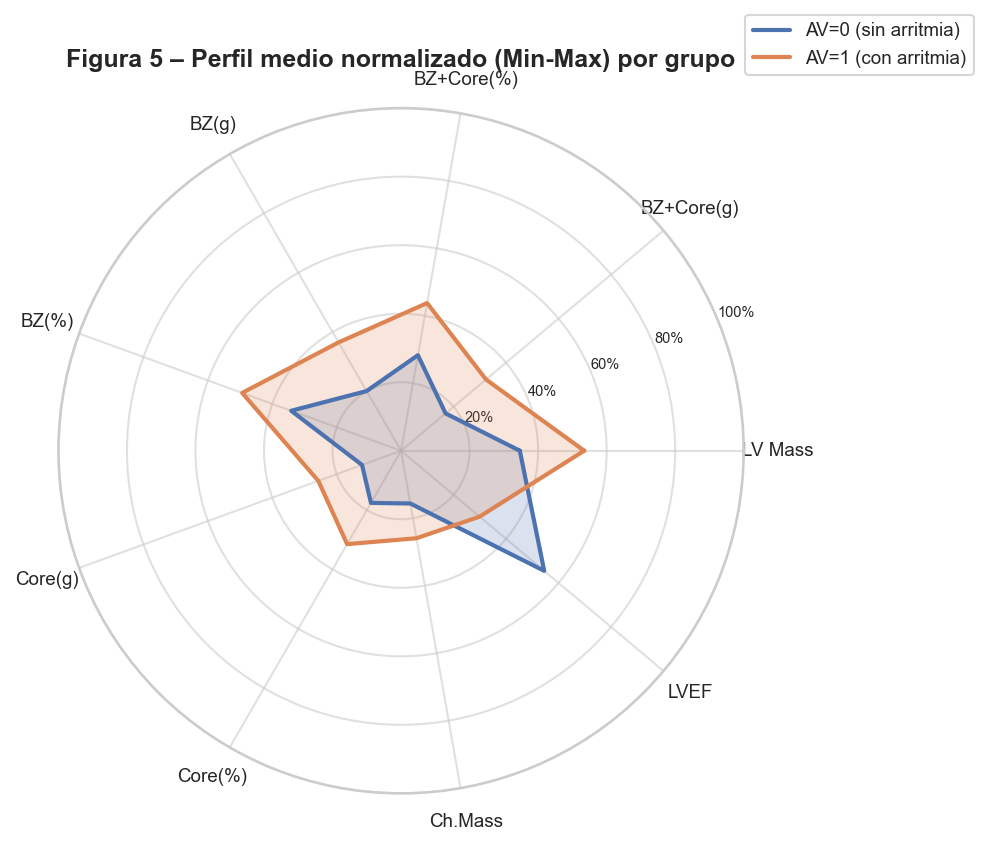

In [11]:
short_names = {
    'LV MASS (g)': 'LV Mass', 'BZ + CORE (g)': 'BZ+Core(g)',
    'BZ + CORE (%)': 'BZ+Core(%)', 'BZ (g)': 'BZ(g)',
    'BZ (%)': 'BZ(%)', 'CORE (g)': 'Core(g)',
    'CORE (%)': 'Core(%)', 'CHANNEL MASS (g)': 'Ch.Mass',
    'LVEF': 'LVEF'
}

# Normalización Min-Max global (sobre todo el dataset)
df_norm = df[marker_cols].copy()
for col in marker_cols:
    mn, mx = df[col].min(), df[col].max()
    df_norm[col] = (df[col] - mn) / (mx - mn) * 100  # escala 0–100%

mean0 = df_norm[df['AV'] == 0].mean()
mean1 = df_norm[df['AV'] == 1].mean()

labels = [short_names.get(c, c) for c in marker_cols]
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

fig5, ax = plt.subplots(figsize=(7, 7),
                         subplot_kw=dict(polar=True))

def radar_plot(ax, values, color, label):
    vals = values.tolist() + [values.iloc[0]]
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.20)

radar_plot(ax, mean0, COLOR_AV0, LABEL_AV0)
radar_plot(ax, mean1, COLOR_AV1, LABEL_AV1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=7)
ax.set_title('Figura 5 – Perfil medio normalizado (Min-Max) por grupo',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.show()


El grupo sano ($AV=0$)apunta hacia el $LVEF$, es decir, mayor fuerza del corazon, mientras que la silueta del grupo con arritmia ($AV=1$) se estira hacia una mayor masa ventricular

## 7. Figura 6 – Scatter + Contornos KDE

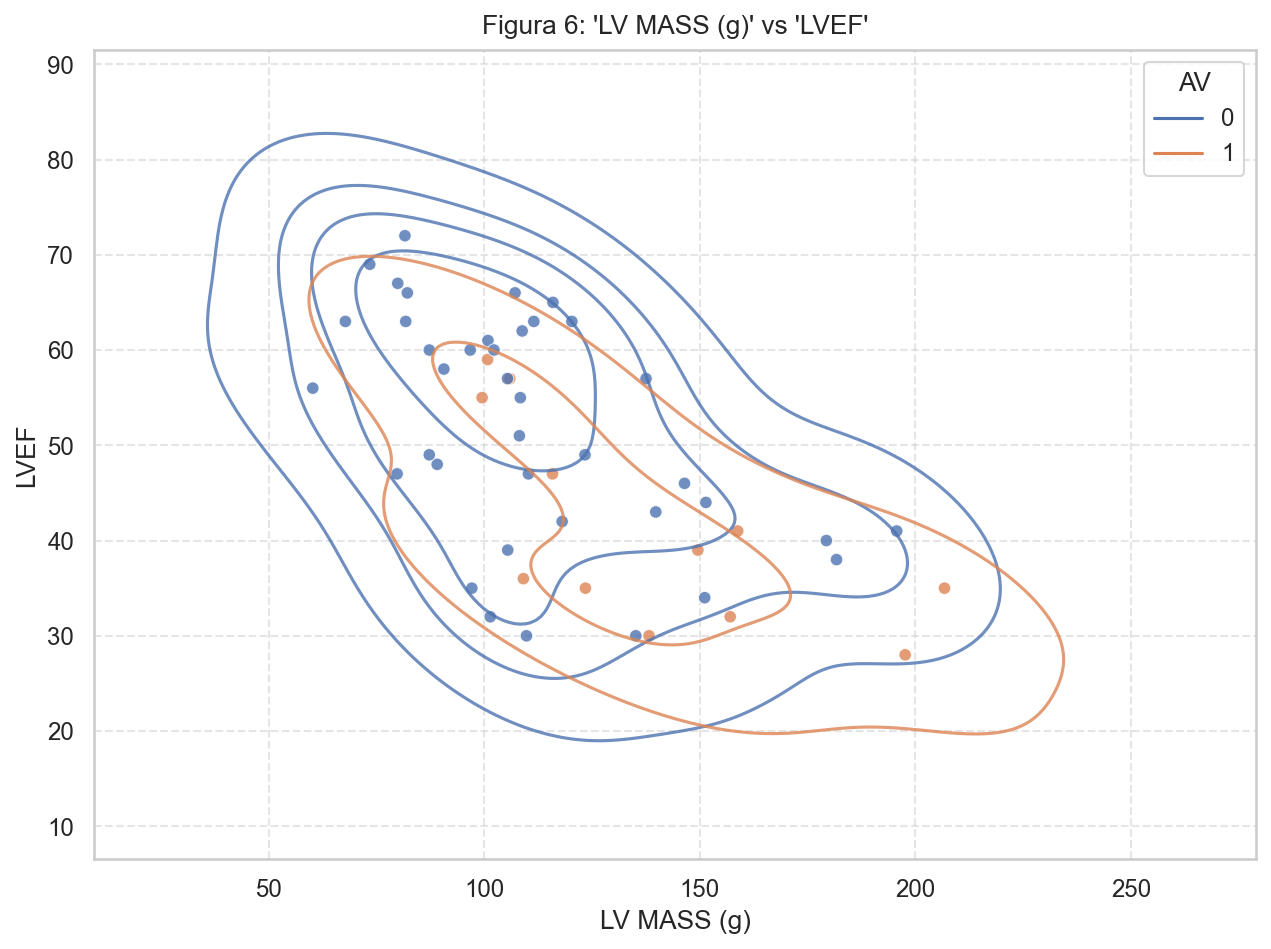

In [12]:
# Vemos según el p-value que 'LV MASS (g)' y 'LVEF' son los más discriminantes
top_2 = ['LV MASS (g)', 'LVEF']

plt.figure(figsize=(10, 7))

# Hacemos un scatter plot coloreado por grupo
sns.scatterplot(data=df, x='LV MASS (g)', y='LVEF', hue='AV', palette=PALETTE, alpha=0.8)

# Superponer contornos KDE 
sns.kdeplot(data=df, x='LV MASS (g)', y='LVEF', hue='AV', palette=PALETTE, levels=5, alpha=0.8)

plt.title("Figura 6: 'LV MASS (g)' vs 'LVEF'")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Las nubes de puntos y los contornos se mezclan bastante. Esto indica que, aunque son los mejores marcadores, no hay una separación perfecta. Hay pacientes con mucha masa muscular que están sanos y otros con poca que están enfermos.
La leve tendencia de los grupos:
- Grupo AV=0 (Azul - Sin arritmia): tienden a estar en la esquina superior izquierda. Tienen un LVEF alto (corazón con fuerza) y un LV MASS más bajo.
- Grupo AV=1 (Naranja - Con arritmia): tienden a desplazarse hacia la derecha y abajo. Tienen el LVEF más caído y, en varios casos, una masa ventricular (LV MASS) mucho mayor.
Los contornos KDE revelan que el "corazón" de la distribución de los enfermos está más abajo que el de los sanos.

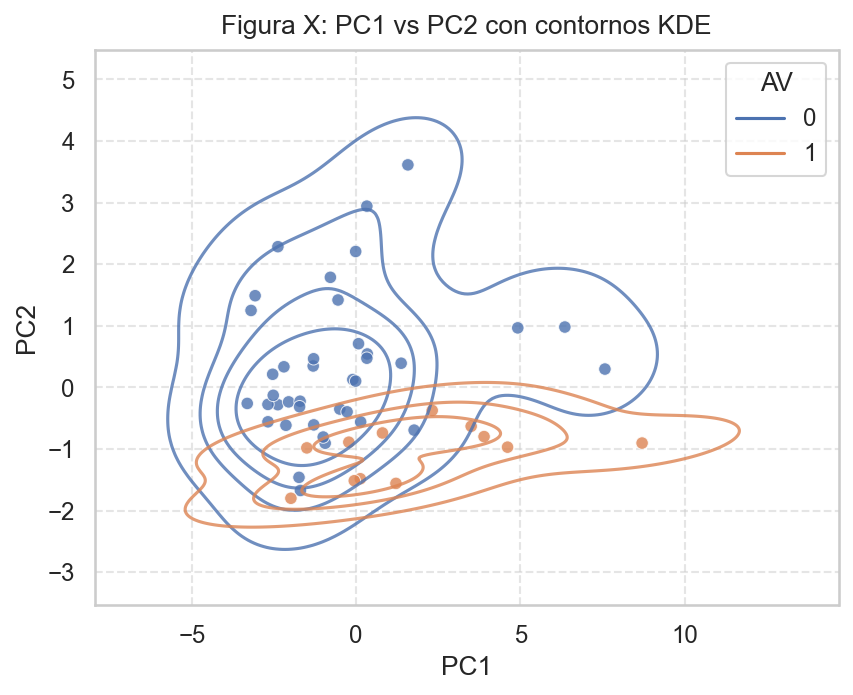

In [13]:
df_num = df.select_dtypes(include=["number"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)


pca = PCA(n_components=None)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)


df_pca = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

# Scatter plot coloreado por grupo
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue=df['AV'],          # variable categórica original
    palette=PALETTE,
    alpha=0.8
)

# Contornos KDE superpuestos
sns.kdeplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue=df['AV'],
    palette=PALETTE,
    levels=5,
    alpha=0.8
)

plt.title("Figura X: PC1 vs PC2 con contornos KDE")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Observamos una mejor separación de los datos utilizando una PCA.

## 8. Conclusiones

**Marcadores significativos identificados:**

- LVEF es el discriminante más potente, con un p = 0.00693. Pacientes con arritmia presentan una fuerza de eyección del ventrículo menor que sin arritmia.

- Marcadores de masa infartada en gramos son más discriminantes que sus equivalentes porcentuales, indicando que la cantidad absoluta de tejido dañado es clínicamente relevante.

**Patrones identificados:**

- Grupos sin arritmia (AV=0) concentran valores más altos en LVEF y bajos en masa infartada, mientras que el grupo con arritmia (AV=1) muestra el patrón opuesto.

- Distancia entre centroides de los datos (Mahalanobis) más alto para LVEF frente a LV MASS. Un paciente con LVEF bajo y LV MASS elevado tiene más posibilidades de tener una arritmia.

**Limitaciones:**

- El sexo no es un predictor significativo, hay un gran desbalance muestral.

- La edad solo es relevante como valor umbral